# Beginner EDA: Device and Email Fraud
This notebook is written with very simple, beginner-friendly Python code. It shows how to calculate and graph the fraud rate for Emails and Devices.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make the graphs a little bigger
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

## 1. Load the Data
We load the two datasets and join them together step-by-step.

In [16]:
# 1. Load transactions (just 500,000 rows to keep it fast)
transactions = pd.read_csv('train_transaction.csv', nrows=500000)

# 2. Load identity data
identity = pd.read_csv('train_identity.csv')

# 3. Merge them together using TransactionID
train = pd.merge(transactions, identity, on='TransactionID', how='left')

print("Data is loaded and merged!")

Data is loaded and merged!


## 2. Graph 1: Email Domain Fraud Risks
If we just check highest fraud rate, we might get emails with only 1 transaction that happened to be fraud (100% rate). To fix this, we'll only check the most popular emails!

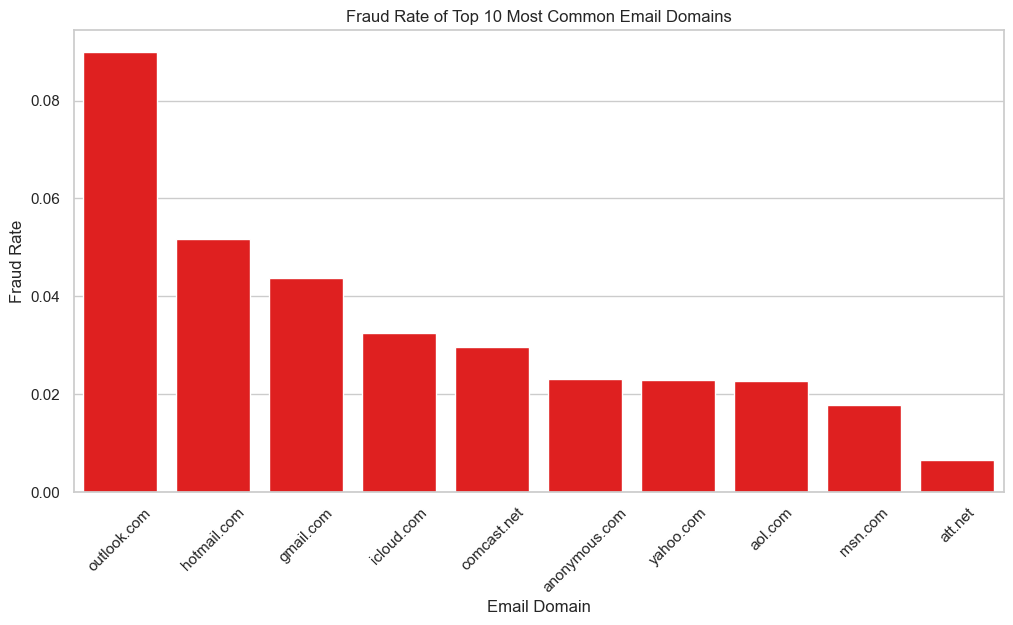

In [17]:
# Step 1: Find the 10 most common email domains
popular_emails = train['P_emaildomain'].value_counts().head(10).index

# Step 2: Keep only rows that have those popular emails
train_emails = train[train['P_emaildomain'].isin(popular_emails)]

# Step 3: Group by Email Domain and calculate the average (mean) of isFraud
email_fraud_rates = train_emails.groupby('P_emaildomain')['isFraud'].mean().reset_index()

# Step 4: Sort from highest to lowest fraud rate
email_fraud_rates = email_fraud_rates.sort_values(by='isFraud', ascending=False)

# Step 5: Draw the graph using Seaborn
sns.barplot(data=email_fraud_rates, x='P_emaildomain', y='isFraud', color='red')

plt.title('Fraud Rate of Top 10 Most Common Email Domains')
plt.xlabel('Email Domain')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45) 
plt.show()

## 3. Graph 2: Device Info Fraud Risks
We use the exact same logic here: filter by the top 10 most popular devices first, so we don't end up with obscure devices having a 100% fraud rate because they only appeared once!

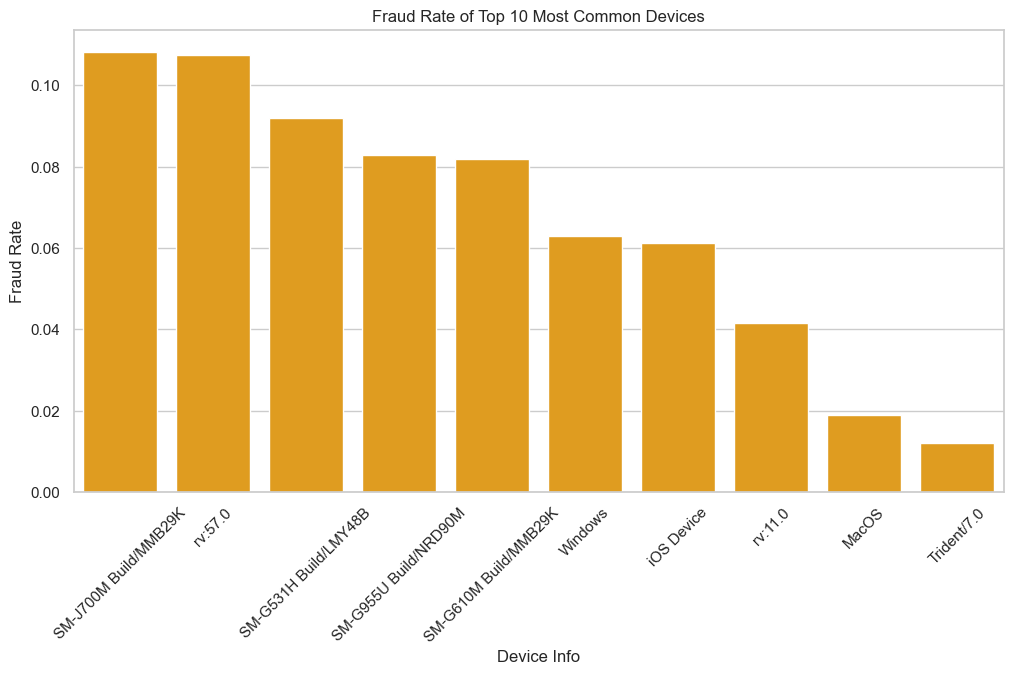

In [18]:
if 'DeviceInfo' in train.columns:
    # Step 1: Find the 10 most common devices
    popular_devices = train['DeviceInfo'].value_counts().head(10).index
    
    # Step 2: Keep only rows that have those popular devices
    train_devices = train[train['DeviceInfo'].isin(popular_devices)]
    
    # Step 3: Group by Device Info and get the average fraud rate
    device_fraud_rates = train_devices.groupby('DeviceInfo')['isFraud'].mean().reset_index()
    
    # Step 4: Sort from highest to lowest fraud rate
    device_fraud_rates = device_fraud_rates.sort_values(by='isFraud', ascending=False)
    
    # Step 5: Draw the graph
    sns.barplot(data=device_fraud_rates, x='DeviceInfo', y='isFraud', color='orange')
    
    plt.title('Fraud Rate of Top 10 Most Common Devices')
    plt.xlabel('Device Info')
    plt.ylabel('Fraud Rate')
    plt.xticks(rotation=45) 
    plt.show()
else:
    print('Device Column is missing!')

## 4. Graph 3: Average Transaction Amount by Fraud Status
Let's see if the average amount of money spent is different for real purchases versus fraudulent purchases.

/var/folders/dx/ktq8wnq17dsf9p9gz65_m8kr0000gn/T/ipykernel_40022/90356000.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_amount, x='isFraud', y='TransactionAmt', palette='Greens_d')


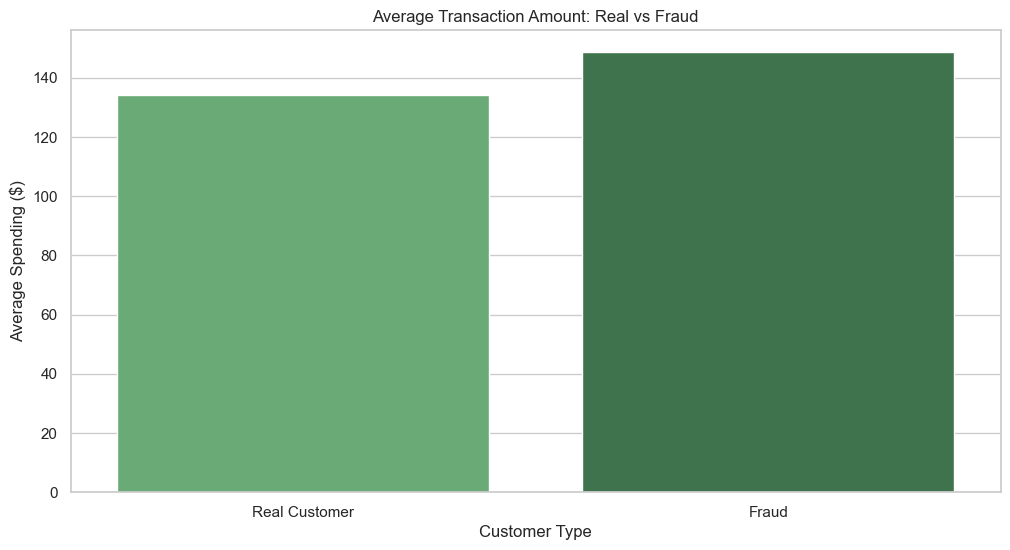

In [19]:
# Step 1: Group by 'isFraud' and calculate the average 'TransactionAmt'
# (0 means Real Customer, 1 means Fraud)
avg_amount = train.groupby('isFraud')['TransactionAmt'].mean().reset_index()

# We can rename the 0 and 1 into words so the graph is easy to read!
avg_amount['isFraud'] = avg_amount['isFraud'].replace({0: 'Real Customer', 1: 'Fraud'})

# Step 2: Draw the graph!
sns.barplot(data=avg_amount, x='isFraud', y='TransactionAmt', palette='Greens_d')

plt.title('Average Transaction Amount: Real vs Fraud')
plt.xlabel('Customer Type')
plt.ylabel('Average Spending ($)')
plt.show()